# Customer Investment Needs — EDA & Preprocessing

**Goal:** Understand customer data, engineer features, and assess whether unsupervised clustering can support a downstream recommendation system.
**Scope:** Preprocessing and exploration only — modelling is in a separate notebook.

> **Note:** Plots are defined in `plots.py` in the same directory.

---

## Notebook Structure

1. Imports & Setup
2. Data Loading & Exploration
3. Data Cleaning
4. Skew Reduction
5. Feature Engineering
6. Exploratory Data Analysis (EDA)
7. Supervised EDA
8. FAMD (Dimensionality Reduction)
9. GMM Clustering
10. Summary, Findings & Next Steps

---
## 1. Imports & Setup

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from scipy.stats import pointbiserialr
import prince
import importlib
import plots
importlib.reload(plots)

# Set global plot style (dark theme, fonts, colors) — aesthetic only
sns.set_theme(style='darkgrid', context='notebook', palette='muted')
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'figure.facecolor': '#1a1a2e',
    'axes.facecolor': '#16213e',
    'text.color': 'white',
    'axes.labelcolor': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'axes.edgecolor': '#444',
    'grid.color': '#333',
})

SEED = 42
np.random.seed(SEED)
print('Setup complete ✓')

Setup complete ✓


---
## 2. Data Loading & Exploration

**Source:** `Dataset2_Needs.xls` — three sheets:
- `Needs`: one row per customer, features + two binary targets
- `Products`: product catalogue with risk profiles
- `Metadata`: column descriptions

**Targets:**
- `IncomeInvestment` — propensity for lump-sum / income-generating products
- `AccumulationInvestment` — propensity for regular contribution products

In [38]:
file_path = 'Dataset2_Needs.xls'

needs_df    = pd.read_excel(file_path, sheet_name='Needs')
products_df = pd.read_excel(file_path, sheet_name='Products')
metadata_df = pd.read_excel(file_path, sheet_name='Metadata')

print('needs_df    :', needs_df.shape)
print('products_df :', products_df.shape)
print('metadata_df :', metadata_df.shape)
print(metadata_df.head())
needs_df.head()

needs_df    : (5000, 10)
products_df : (11, 3)
metadata_df : (29, 2)
        Metadata                     Unnamed: 1
0        Clients                            NaN
1             ID                   Numerical ID
2            Age                  Age, in years
3         Gender  Gender (Female = 1, Male = 0)
4  FamilyMembers           Number of components


,ID,Age,Gender,FamilyMembers,FinancialEducation,RiskPropensity,Income,Wealth,IncomeInvestment,AccumulationInvestment
0,1,60,0,2,0.228685,0.233355,68.181525,53.260067,0,1
1,2,78,0,2,0.358916,0.170911,21.807595,135.550048,1,0
2,3,33,1,2,0.317515,0.249703,23.252747,66.303678,0,1
3,4,69,1,4,0.767685,0.654597,166.189034,404.997689,1,1
4,5,58,0,3,0.429719,0.349039,21.186723,58.911930,0,0


In [39]:
print('Dtypes:\n', needs_df.dtypes)
print('\nMissing values:\n', needs_df.isnull().sum())
needs_df.describe()

Dtypes:
 ID                          int64
Age                         int64
Gender                      int64
FamilyMembers               int64
FinancialEducation        float64
RiskPropensity            float64
Income                    float64
Wealth                    float64
IncomeInvestment            int64
AccumulationInvestment      int64
dtype: object

Missing values:
 ID                        0
Age                       0
Gender                    0
FamilyMembers             0
FinancialEducation        0
RiskPropensity            0
Income                    0
Wealth                    0
IncomeInvestment          0
AccumulationInvestment    0
dtype: int64


,ID,Age,Gender,FamilyMembers,FinancialEducation,RiskPropensity,Income,Wealth,IncomeInvestment,AccumulationInvestment
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,55.253400,0.492000,2.510600,0.419123,0.362686,62.994324,93.806264,0.383600,0.513200
std,1443.520003,11.971694,0.499986,0.761842,0.151383,0.151124,44.359771,105.471004,0.486311,0.499876
min,1.000000,18.000000,0.000000,1.000000,0.036099,0.024790,1.537765,1.057415,0.000000,0.000000
25%,1250.750000,47.000000,0.000000,2.000000,0.308067,0.246444,30.596490,38.311097,0.000000,0.000000
50%,2500.500000,55.000000,0.000000,3.000000,0.416735,0.354526,53.399368,66.070582,0.000000,1.000000
75%,3750.250000,63.000000,1.000000,3.000000,0.523393,0.467125,84.122304,114.824753,1.000000,1.000000
max,5000.000000,97.000000,1.000000,5.000000,0.902933,0.882709,365.323385,2233.228433,1.000000,1.000000


---
## 3. Data Cleaning

- Drop `ID` (not informative for modelling)
- Shuffle rows reproducibly
- Separate features from targets
- Check class balance

In [40]:
needs_df.drop(columns='ID', inplace=True)

df = needs_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

x_df     = df[['Age', 'Gender', 'FamilyMembers', 'FinancialEducation',
                'RiskPropensity', 'Income', 'Wealth']]
y_inc_df = df['IncomeInvestment']
y_acc_df = df['AccumulationInvestment']

print(f'Features: {x_df.shape}  |  Targets: {y_inc_df.shape}')

Features: (5000, 7)  |  Targets: (5000,)


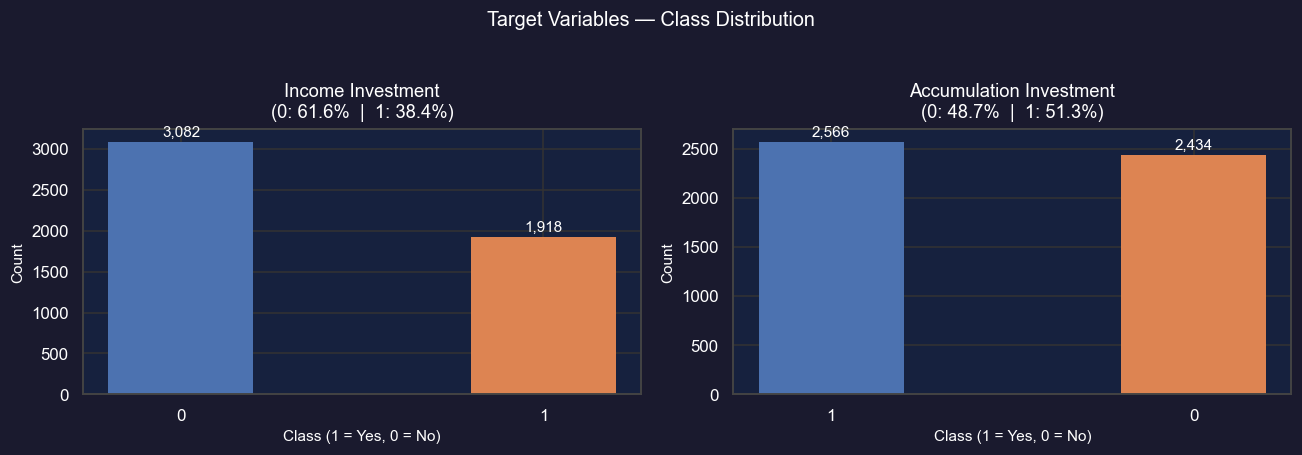

In [41]:
plots.plot_target_distribution(df)

---
## 4. Skew Reduction

`Wealth` and `Income` are heavily right-skewed. We apply `log1p` — safe for zero values.

In [42]:
transformed_df = df.copy()

transformed_df['Wealth_log'] = np.log1p(transformed_df['Wealth'])
transformed_df['Income_log'] = np.log1p(transformed_df['Income'])

skew_table = pd.DataFrame({
    'Original Skew': [df['Wealth'].skew(), df['Income'].skew()],
    'After log1p':   [transformed_df['Wealth_log'].skew(), transformed_df['Income_log'].skew()],
}, index=['Wealth', 'Income'])

print(skew_table.round(3))

        Original Skew  After log1p
Wealth          5.831       -0.371
Income          1.377       -0.618


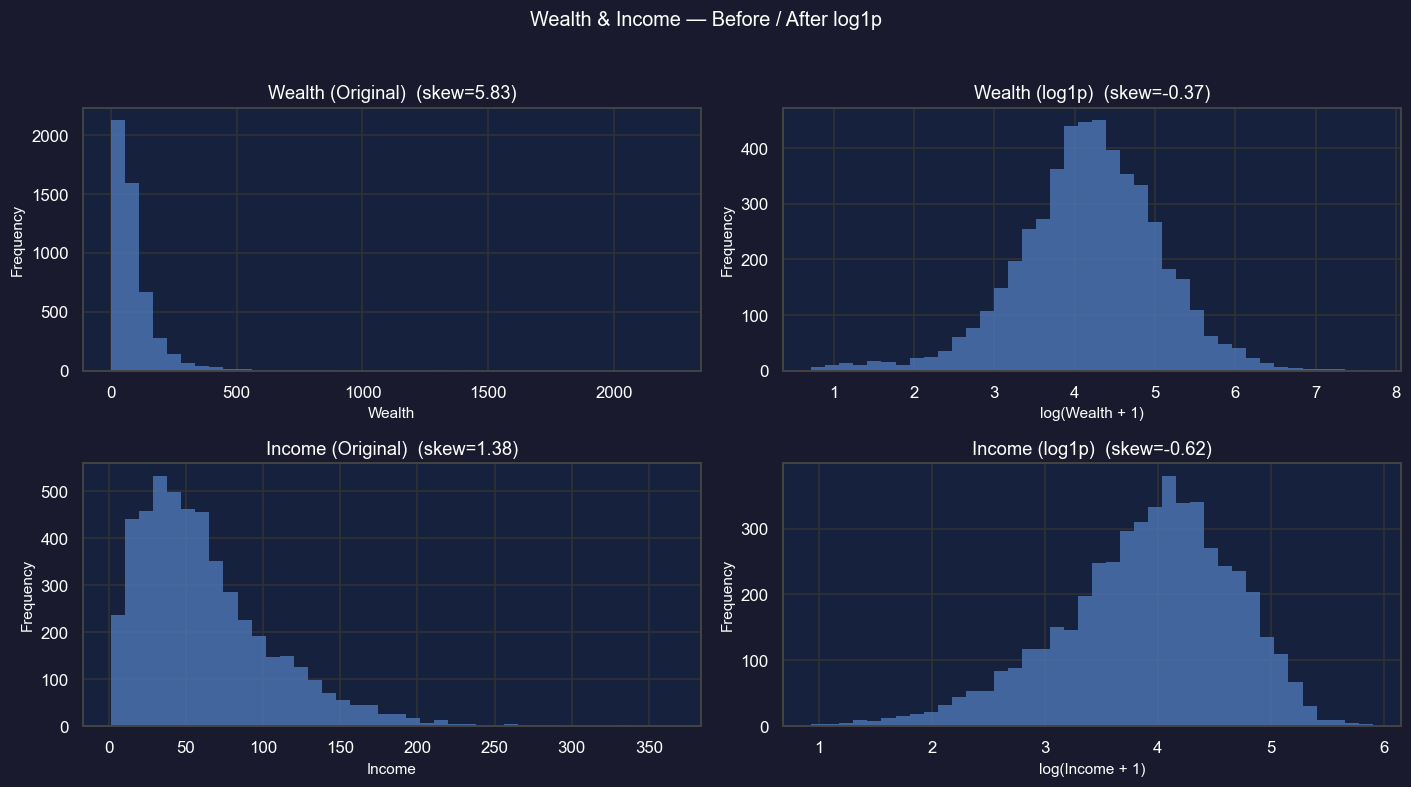

In [43]:
plots.plot_skew_comparison(transformed_df)

,Feature,Max_Signal,Max_Multicollinearity
31,Income_log_DIV_Age,0.245404,0.761644
29,Wealth_log_DIV_Age,0.123385,0.761644
24,FamilyMembers_DIV_Age,0.146153,0.789539
11,FamilyMembers_X_FinancialEducation,0.097970,0.808754
12,FamilyMembers_X_RiskPropensity,0.084849,0.808754
26,FinancialEducation_DIV_FamilyMembers,0.038551,0.809321
28,RiskPropensity_DIV_FamilyMembers,0.029415,0.809321
25,FinancialEducation_DIV_Age,0.088680,0.810876
1,Age_X_FamilyMembers,0.225772,0.840989
27,RiskPropensity_DIV_Age,0.087490,0.847454


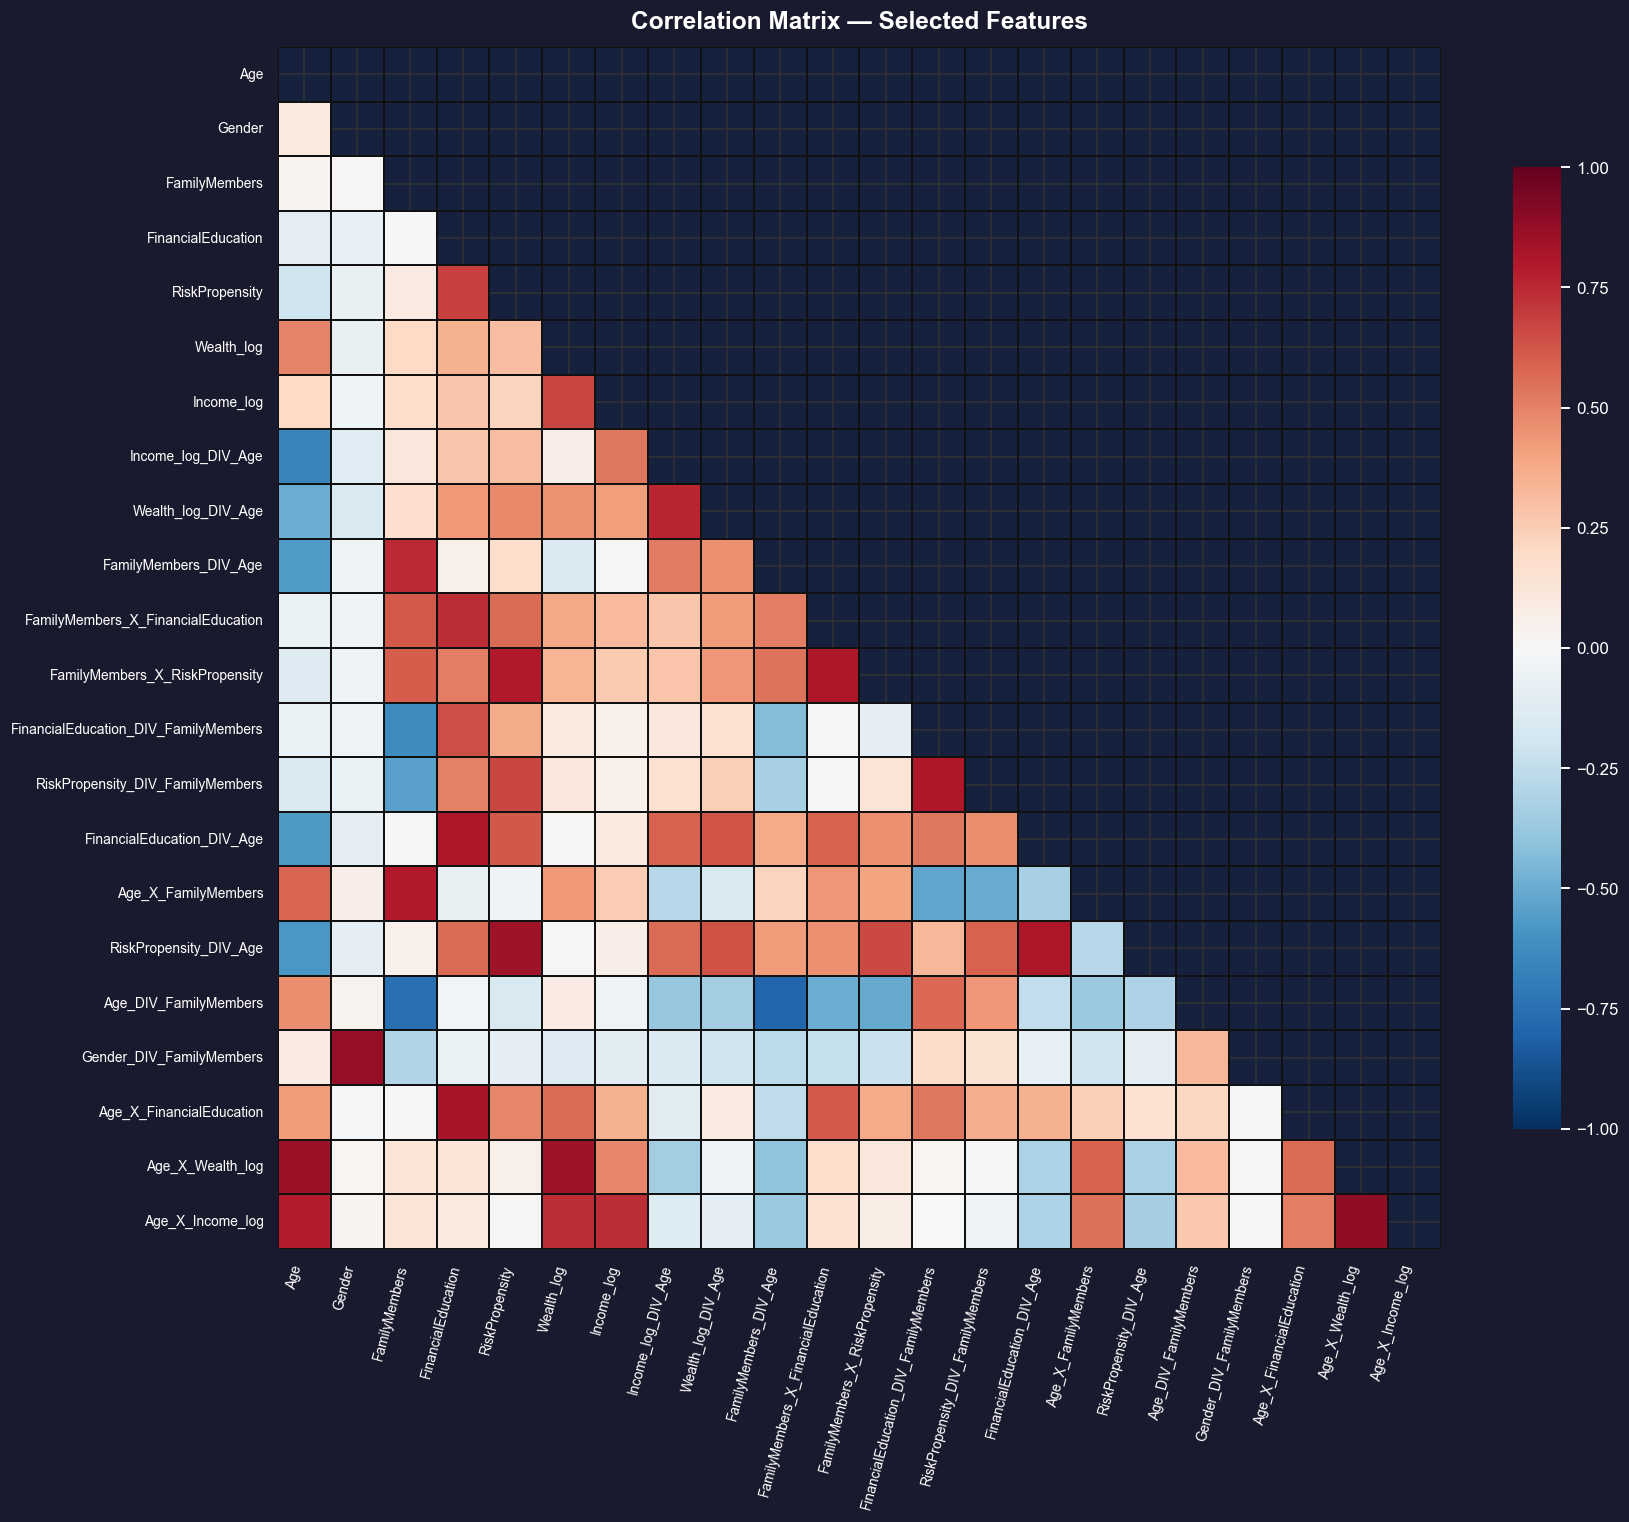

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

def engineer_and_evaluate(df, base_columns, targets):
    df_ext = df.copy()
    
    # 1. Generate Interactions (Multiplications & Safe Divisions)
    for c1, c2 in combinations(base_columns, 2):
        df_ext[f"{c1}_X_{c2}"] = df[c1] * df[c2]
        
    denominators = ['Age', 'FamilyMembers']
    for num in base_columns:
        for den in denominators:
            if num != den: # we check that they are not the same feature
                df_ext[f"{num}_DIV_{den}"] = df[num] / (df[den] + 1e-5) #we create the list of denominators and numerators and check they are denom is not equal to 0

    # 2. Evaluate Features (Predictive Power vs. Multicollinearity)
    corr = df_ext.corr()
    new_features = [col for col in df_ext.columns if col not in df.columns]
    results = []
    
    for feat in new_features:
        max_signal = corr.loc[feat, targets].abs().max() # Target correlation
        other_feats = [col for col in df_ext.columns if col not in targets + [feat]]
        max_collin = corr.loc[feat, other_feats].abs().max() # Other feature correlation
        
        results.append({'Feature': feat, 'Max_Signal': max_signal, 'Max_Multicollinearity': max_collin})
    
    # Rank FIRST by minimum collinearity (ascending=True), THEN by predictive power (ascending=False)
    results_df = pd.DataFrame(results).sort_values(
        by=['Max_Multicollinearity', 'Max_Signal'], ascending=[True, False]
    )
    
    return df_ext, results_df, corr

def plot_correlation_matrix2(corr_matrix, features):
    subset_corr = corr_matrix.loc[features, features]
    fig, ax = plt.subplots(figsize=(16, 14))
    mask = np.triu(np.ones_like(subset_corr, dtype=bool))
    show_annot = len(features) <= 15
    
    sns.heatmap(subset_corr, mask=mask, annot=show_annot, fmt='.2f',
                cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                linewidths=0.2, linecolor='#111', ax=ax, cbar_kws={'shrink': 0.8})
    ax.set_title('Correlation Matrix — Selected Features', fontsize=16, fontweight='bold', pad=12)
    plt.xticks(rotation=75, ha='right', fontsize=9)
    plt.yticks(fontsize=9)
    plt.tight_layout()
    plt.show()

# --- EXECUTION ---
# Assuming 'transformed_df' is your base dataframe
base_cols = ['Age', 'Gender', 'FamilyMembers', 'FinancialEducation', 'RiskPropensity', 'Wealth_log', 'Income_log']
targets = ['IncomeInvestment', 'AccumulationInvestment']

# Generate and evaluate
df_extended, evaluation_df, full_corr = engineer_and_evaluate(transformed_df, base_cols, targets)

# Display top 10 best candidates
display(evaluation_df.head(10).style.background_gradient(cmap='coolwarm'))

# Plot matrix for the top 15 features to avoid clutter
top_features = base_cols + evaluation_df['Feature'].head(15).tolist()
plot_correlation_matrix2(full_corr, top_features)

We combined all the different base features we had to see if we were missing any potential engineered feature that could be useful for our analysis. We can see that Income_log_DIV_Age has relatively high correlation with its base features and the predictive power is quite good. We then decide to insert it in our list of engineered features. In terms of business application it also has quite an interest meaning as when your age increases you tend to earn more.

---
## 5. Feature Engineering

| Feature | Formula | Rationale |
|---|---|---|
| `IncomePerFamilyMember_log` | log1p(Income / FamilyMembers) | Disposable income proxy |
| `Income_Wealth_Ratio_log` | log1p(Income / Wealth) | Lifecycle stage: accumulator vs. depleter |
| `SophisticationScore` | FinancialEducation × RiskPropensity | ⚠️ Highly collinear with inputs (~0.87–0.91) — evaluated in supervised EDA |

In [45]:
feature_df = transformed_df.copy()

# Per-capita income
feature_df['IncomePerFamilyMember'] = (
    feature_df['Income'] / feature_df['FamilyMembers'].replace(0, np.nan)
).fillna(feature_df['Income'].median() / feature_df['FamilyMembers'].median())
feature_df['IncomePerFamilyMember_log'] = np.log1p(feature_df['IncomePerFamilyMember'])

# Financial lifecycle ratio
feature_df['Income_Wealth_Ratio'] = (
    feature_df['Income'] / feature_df['Wealth'].replace(0, np.nan)
).fillna(0)
feature_df['Income_Wealth_Ratio_log'] = np.log1p(feature_df['Income_Wealth_Ratio'])

# Behavioural interaction
feature_df['SophisticationScore'] = feature_df['FinancialEducation'] * feature_df['RiskPropensity']

# Gender as categorical (required by FAMD)
feature_df['Gender'] = feature_df['Gender'].astype('category')

# IncomeLog divided by Age feature
feature_df['IncomeDivAge'] = feature_df['Income'] * feature_df['Age']


NUMERICAL_FEATURES = [
    'Age', 'FamilyMembers', 'FinancialEducation', 'RiskPropensity',
    'Wealth_log', 'Income_log',
    'IncomePerFamilyMember_log', 'Income_Wealth_Ratio_log',
    'SophisticationScore', 'IncomeDivAge'
]
CATEGORICAL_FEATURES = ['Gender']
ALL_FEATURES = NUMERICAL_FEATURES + CATEGORICAL_FEATURES

feature_df = feature_df[ALL_FEATURES]
print(f'Feature matrix: {feature_df.shape}')
print(feature_df.dtypes)

Feature matrix: (5000, 11)
Age                             int64
FamilyMembers                   int64
FinancialEducation            float64
RiskPropensity                float64
Wealth_log                    float64
Income_log                    float64
IncomePerFamilyMember_log     float64
Income_Wealth_Ratio_log       float64
SophisticationScore           float64
IncomeDivAge                  float64
Gender                       category
dtype: object


---
## 6. Exploratory Data Analysis (EDA)

Feature distributions and pairwise correlations after engineering.

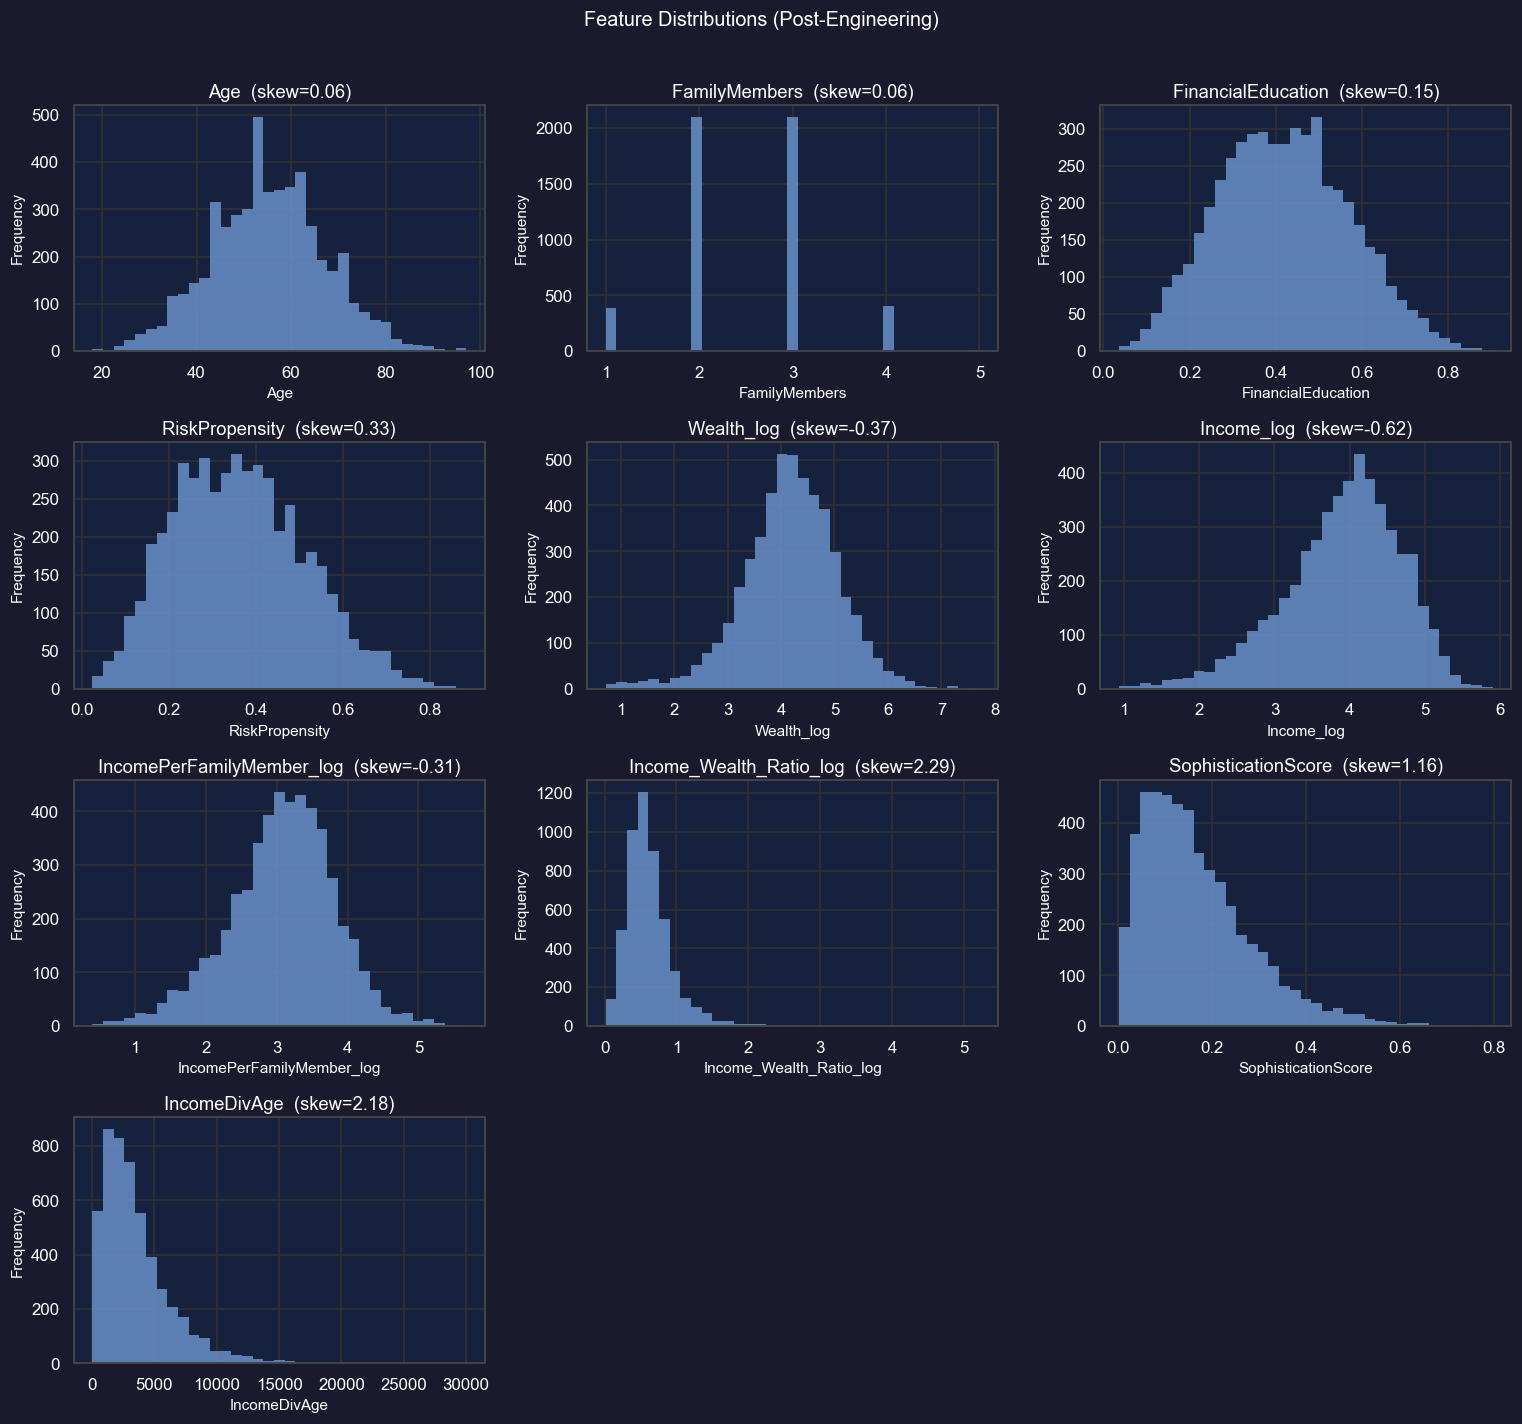

In [46]:
plots.plot_feature_distributions(feature_df, NUMERICAL_FEATURES)

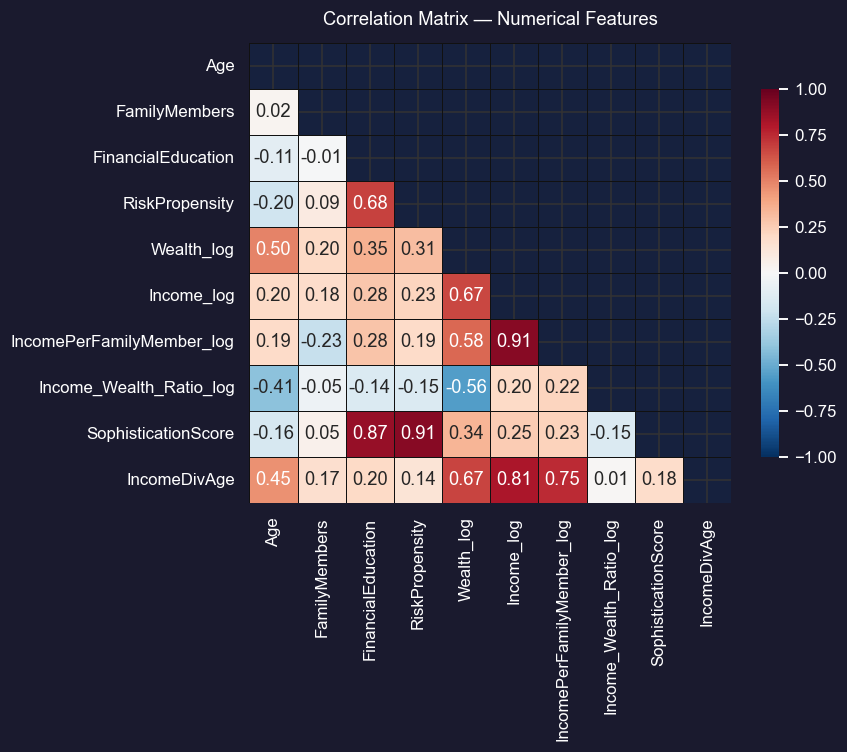

High-correlation pairs (|r| > 0.7):
                Feature A                 Feature B  Correlation
      SophisticationScore            RiskPropensity     0.907942
IncomePerFamilyMember_log                Income_log     0.907685
      SophisticationScore        FinancialEducation     0.873350
             IncomeDivAge                Income_log     0.813650
             IncomeDivAge IncomePerFamilyMember_log     0.747660


In [47]:
plots.plot_correlation_matrix(feature_df, NUMERICAL_FEATURES)

---
## 7. Supervised EDA

How features relate to the two targets — informs feature selection before modelling.

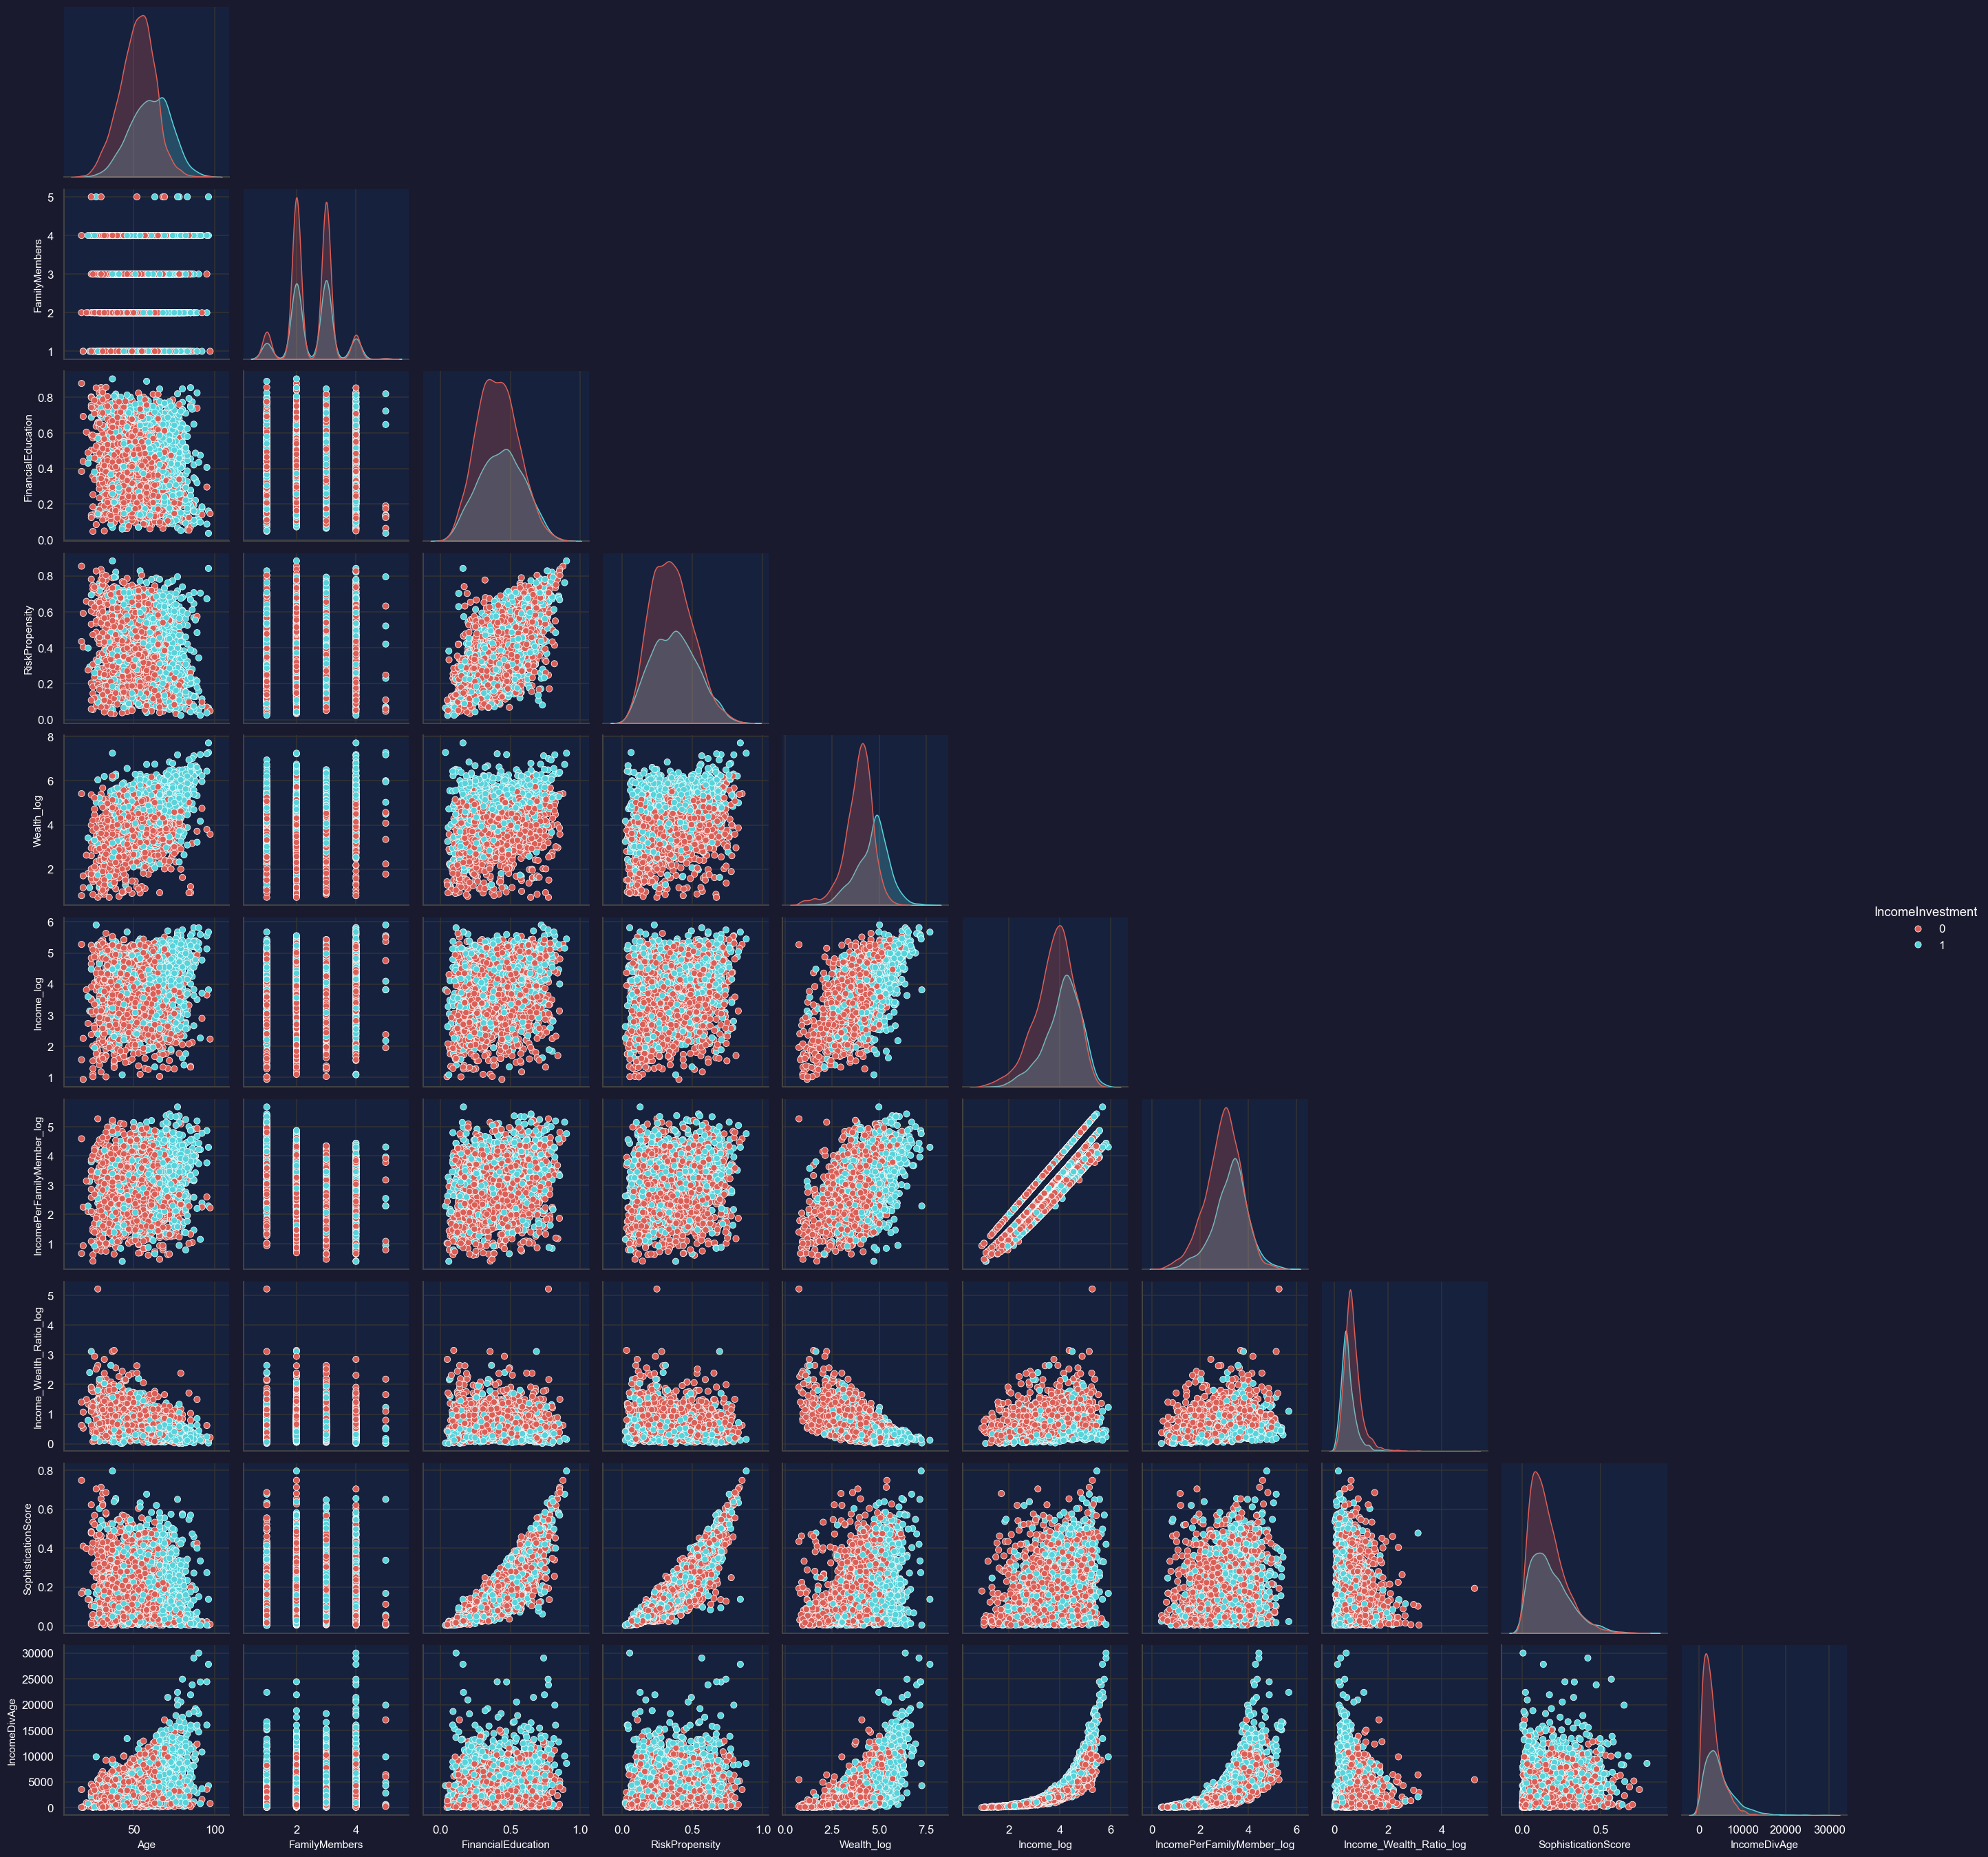

In [48]:
plot_df = feature_df.copy()
plot_df['IncomeInvestment'] = df['IncomeInvestment'].values
plot_df['AccumulationInvestment'] = df['AccumulationInvestment'].values

colour = sns.color_palette("hls", 2)
_ = sns.pairplot(plot_df,
                 hue='IncomeInvestment',
                 corner=True,
                 palette=colour,
                 vars=NUMERICAL_FEATURES)
plt.show()

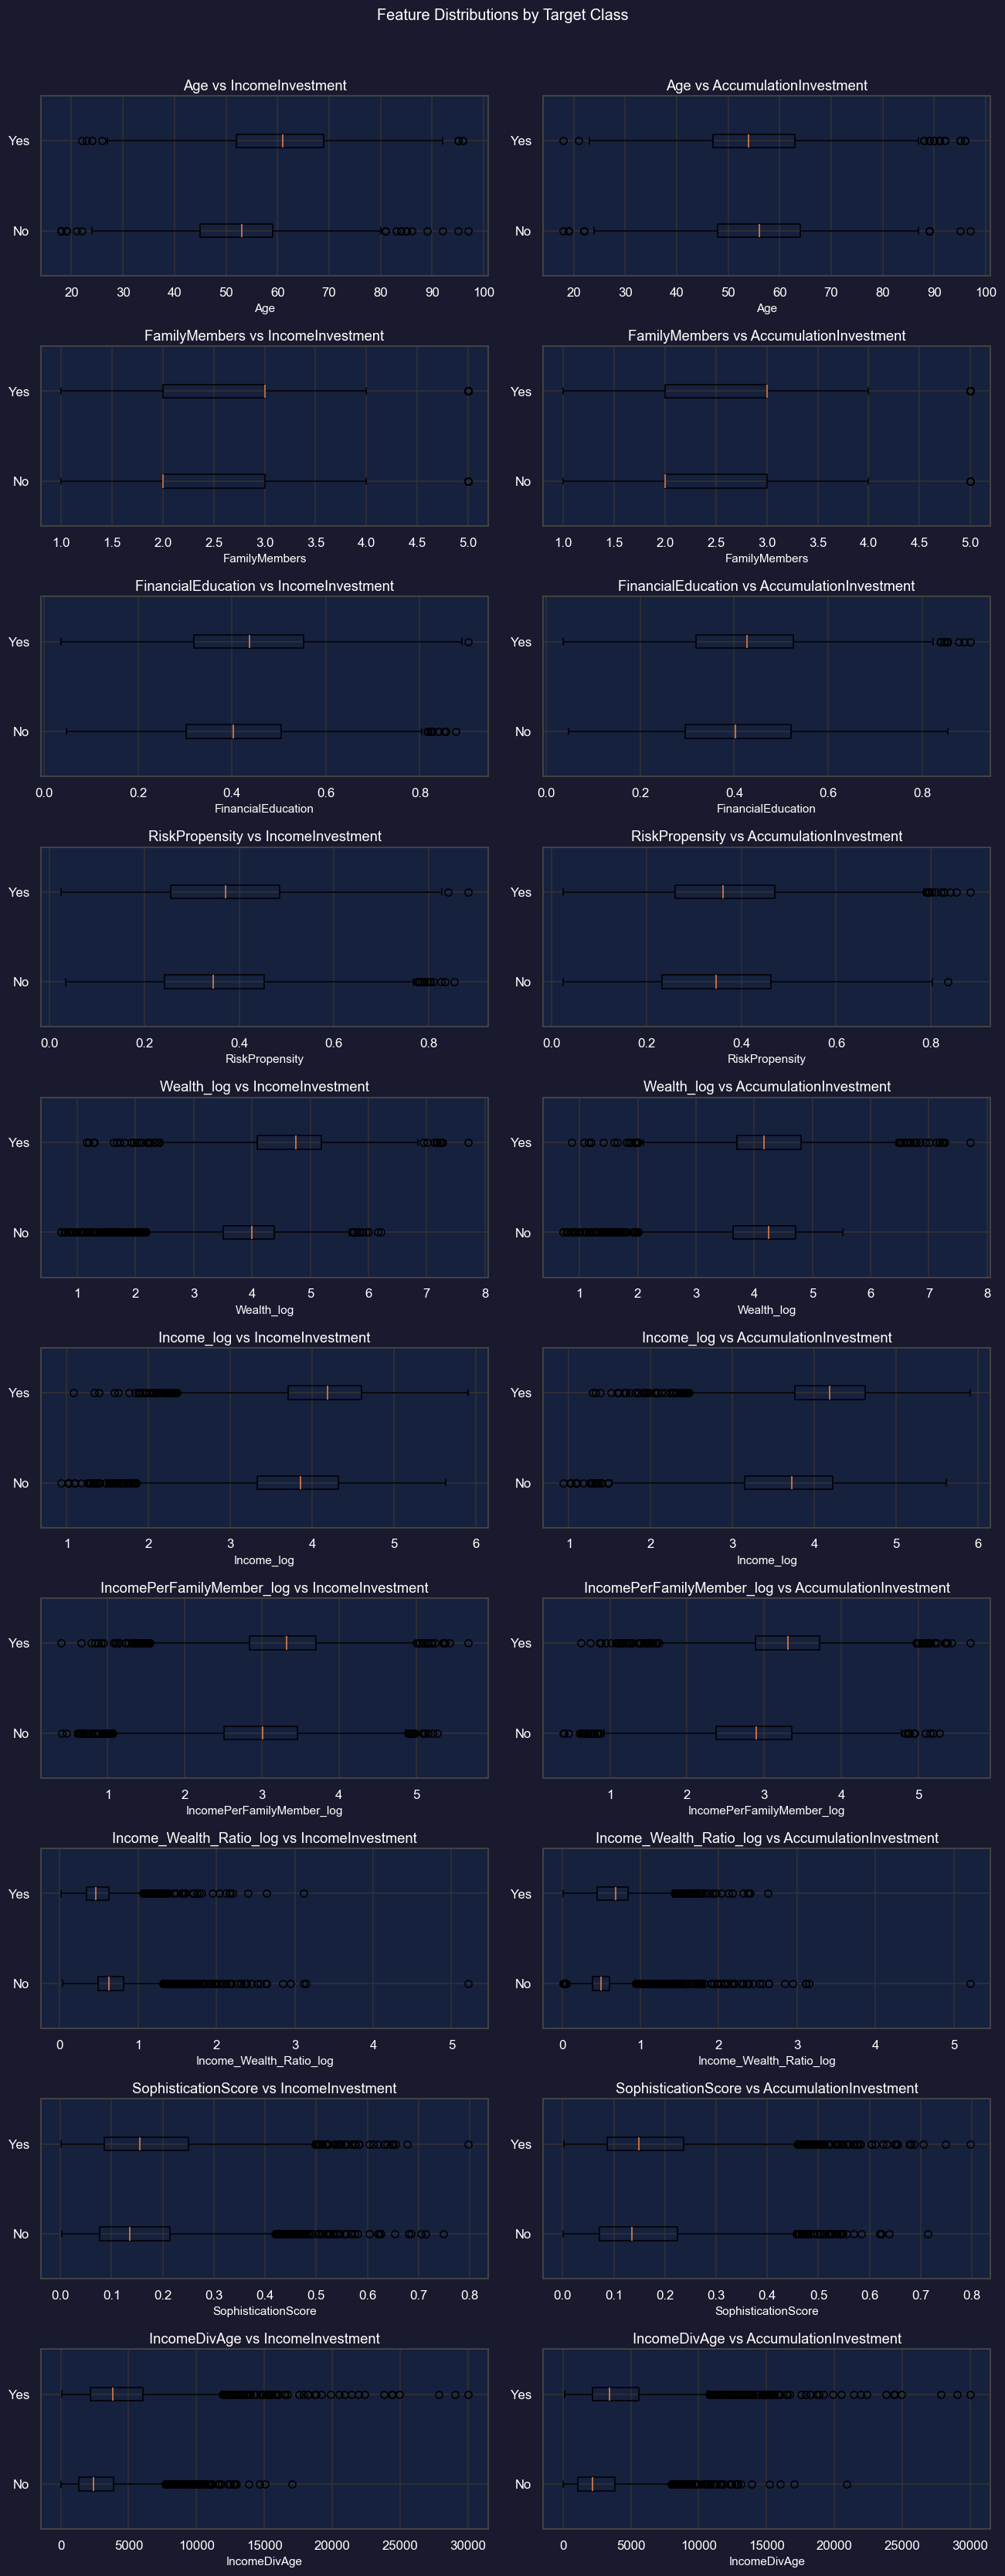

In [49]:
plots.plot_feature_vs_target(plot_df, NUMERICAL_FEATURES)

In [50]:
rows = []
for col in NUMERICAL_FEATURES:
    for target in ['IncomeInvestment', 'AccumulationInvestment']:
        r, p = pointbiserialr(plot_df[target], plot_df[col])
        rows.append({'Feature': col, 'Target': target,
                     'Correlation': round(r, 3), 'p-value': round(p, 4)})

corr_df = pd.DataFrame(rows).sort_values(['Target', 'Correlation'], ascending=[True, False])
print(corr_df.to_string(index=False))

                  Feature                 Target  Correlation  p-value
               Income_log AccumulationInvestment        0.322   0.0000
IncomePerFamilyMember_log AccumulationInvestment        0.292   0.0000
             IncomeDivAge AccumulationInvestment        0.252   0.0000
  Income_Wealth_Ratio_log AccumulationInvestment        0.195   0.0000
               Wealth_log AccumulationInvestment        0.119   0.0000
       FinancialEducation AccumulationInvestment        0.068   0.0000
           RiskPropensity AccumulationInvestment        0.068   0.0000
            FamilyMembers AccumulationInvestment        0.067   0.0000
      SophisticationScore AccumulationInvestment        0.067   0.0000
                      Age AccumulationInvestment       -0.014   0.3395
               Wealth_log       IncomeInvestment        0.404   0.0000
                      Age       IncomeInvestment        0.334   0.0000
             IncomeDivAge       IncomeInvestment        0.289   0.0000
      

### Supervised EDA — Findings

**AccumulationInvestment** — driven by income and cash flow.

| Top Features | Correlation |
|---|---|
| `Income_log` | +0.32 |
| `IncomePerFamilyMember_log` | +0.29 |
| `Income_Wealth_Ratio_log` | +0.20 |
| `Age` | -0.01 *(not significant)* |

**IncomeInvestment** — driven by wealth and age.

| Top Features | Correlation |
|---|---|
| `Wealth_log` | +0.40 |
| `Age` | +0.33 |
| `Income_Wealth_Ratio_log` | -0.25 |

`Income_Wealth_Ratio_log` has **opposite signs for the two targets** — the most informative engineered feature.

**Boxplot findings:** no single feature cleanly separates either target. Signal is spread across many weak features — ensemble methods (Random Forest, Gradient Boosting) are likely better suited than linear models.

**Feature decision:** `SophisticationScore` dropped — correlations (0.067 / 0.093) add nothing beyond its parent features.

In [51]:
feature_df = feature_df.drop(columns='SophisticationScore')
NUMERICAL_FEATURES = [f for f in NUMERICAL_FEATURES if f != 'SophisticationScore']
ALL_FEATURES = NUMERICAL_FEATURES + CATEGORICAL_FEATURES

print(f'Features after drop: {feature_df.shape[1]}')
print(feature_df.columns.tolist())

Features after drop: 10
['Age', 'FamilyMembers', 'FinancialEducation', 'RiskPropensity', 'Wealth_log', 'Income_log', 'IncomePerFamilyMember_log', 'Income_Wealth_Ratio_log', 'IncomeDivAge', 'Gender']


---
## 8. FAMD (Factor Analysis of Mixed Data)

Handles mixed numerical + categorical features in a single reduction step — no manual scaling or encoding needed.

In [52]:
N_COMPONENTS = 8
famd = prince.FAMD(n_components=N_COMPONENTS, n_iter=10, copy=True,
                   check_input=True, engine='sklearn', random_state=42)

X_famd = famd.fit_transform(feature_df.copy())
X_famd.columns = [f'Dim_{i+1}' for i in range(N_COMPONENTS)]

explained_var  = famd.percentage_of_variance_
cumulative_var = np.cumsum(explained_var)

print('Variance explained per component:')
for k, (ev, cv) in enumerate(zip(explained_var, cumulative_var), 1):
    print(f'  Dim {k}: {ev:.2f}%   cumulative: {cv:.2f}%')
print(f'\nTotal ({N_COMPONENTS} dims): {cumulative_var[-1]:.2f}%')

Variance explained per component:
  Dim 1: 2.95%   cumulative: 2.95%
  Dim 2: 1.64%   cumulative: 4.59%
  Dim 3: 1.57%   cumulative: 6.16%
  Dim 4: 1.51%   cumulative: 7.66%
  Dim 5: 1.41%   cumulative: 9.08%
  Dim 6: 1.32%   cumulative: 10.40%
  Dim 7: 1.29%   cumulative: 11.69%
  Dim 8: 1.19%   cumulative: 12.88%

Total (8 dims): 12.88%


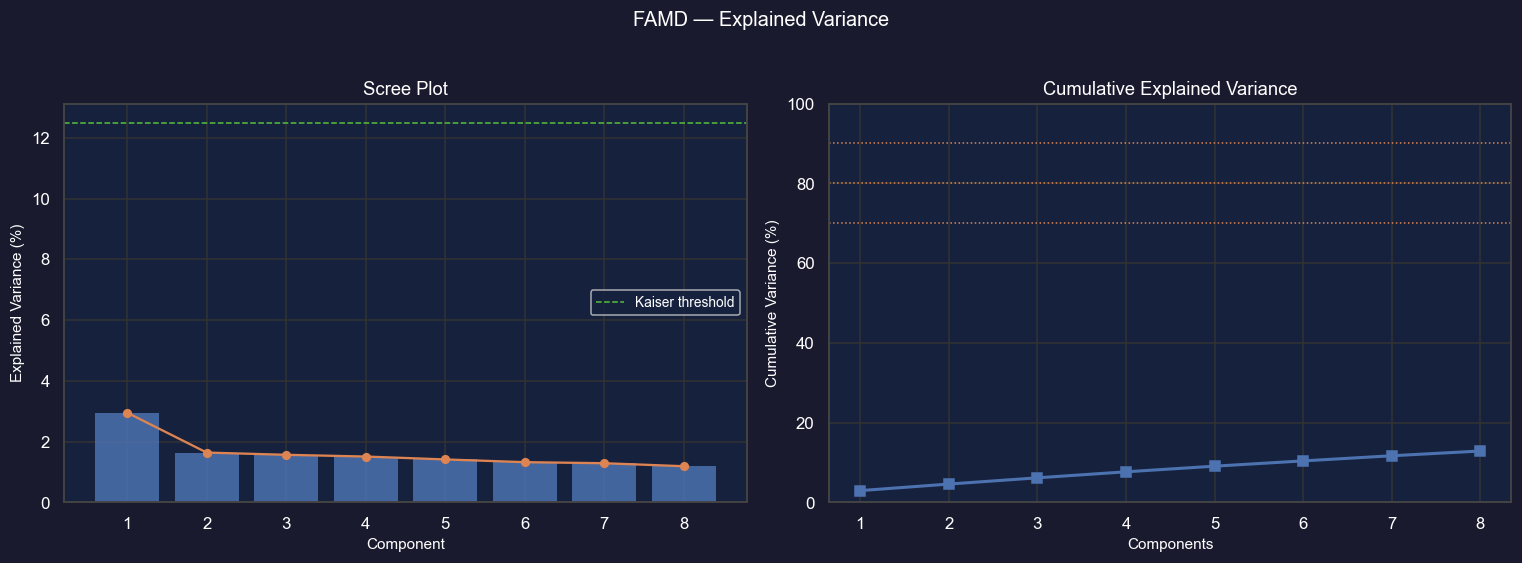

In [53]:
plots.plot_scree(explained_var, cumulative_var)

### Key finding:
The low explained variance confirms feature independence — no dominant latent structure — consistent with the weak clustering signal found downstream

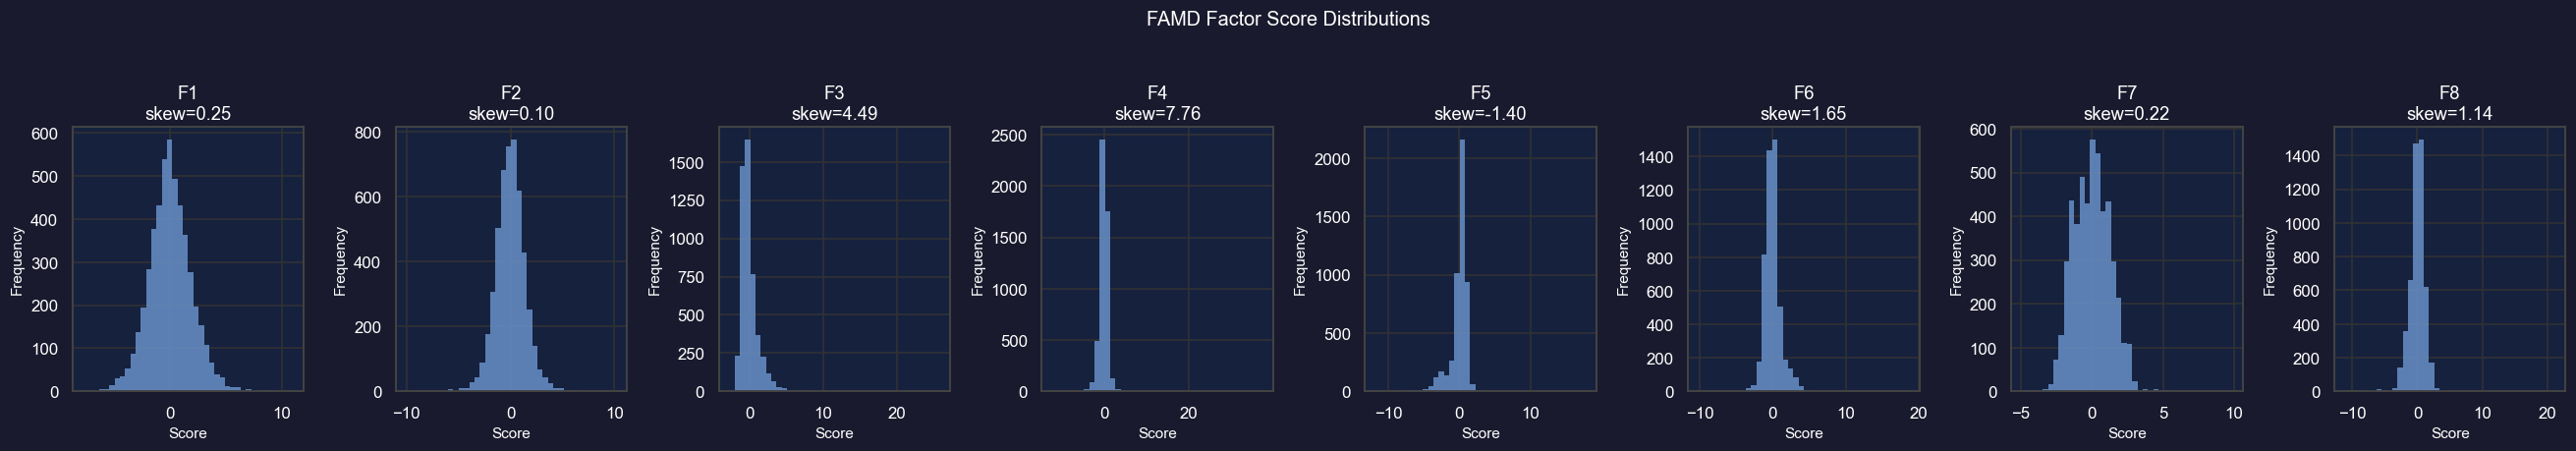

⚠️  High skew: ['F3', 'F4']


In [54]:
factor_cols = [f'F{i+1}' for i in range(N_COMPONENTS)]
factors_df  = pd.DataFrame(X_famd.values, columns=factor_cols, index=feature_df.index)

plots.plot_factor_distributions(factors_df, factor_cols)

skews   = factors_df.skew().round(3)
flagged = skews[skews.abs() > 2.0]
if len(flagged):
    print(f'⚠️  High skew: {flagged.index.tolist()}')
else:
    print('✓ Factor distributions are reasonably symmetric.')

---
## 9. GMM Clustering

Soft clustering — each customer gets a probability per cluster rather than a hard label. Sweep k = 2…10; BIC is the primary selection criterion.

In [55]:
K_RANGE    = range(2, 11)
bic_scores = []
aic_scores = []
sil_scores = []
F_array    = factors_df.values

for k in K_RANGE:
    gmm = GaussianMixture(n_components=k, covariance_type='full',
                          n_init=5, random_state=SEED)
    gmm.fit(F_array)
    labels = gmm.predict(F_array)
    bic_scores.append(gmm.bic(F_array))
    aic_scores.append(gmm.aic(F_array))
    sil_scores.append(silhouette_score(F_array, labels))
    print(f'  k={k:2d}  BIC={bic_scores[-1]:>12,.1f}  '
          f'AIC={aic_scores[-1]:>12,.1f}  Sil={sil_scores[-1]:.4f}')

print('\nSweep complete.')

  k= 2  BIC=   115,440.7  AIC=   114,860.7  Sil=0.2854
  k= 3  BIC=   108,536.6  AIC=   107,663.3  Sil=0.1577
  k= 4  BIC=   106,349.2  AIC=   105,182.7  Sil=0.0925
  k= 5  BIC=   105,053.9  AIC=   103,594.1  Sil=0.0315
  k= 6  BIC=   103,690.7  AIC=   101,937.6  Sil=0.0125
  k= 7  BIC=   101,951.6  AIC=    99,905.2  Sil=0.0267
  k= 8  BIC=   100,345.6  AIC=    98,005.9  Sil=0.0140
  k= 9  BIC=    99,043.2  AIC=    96,410.3  Sil=0.0105
  k=10  BIC=    98,400.5  AIC=    95,474.3  Sil=0.0115

Sweep complete.


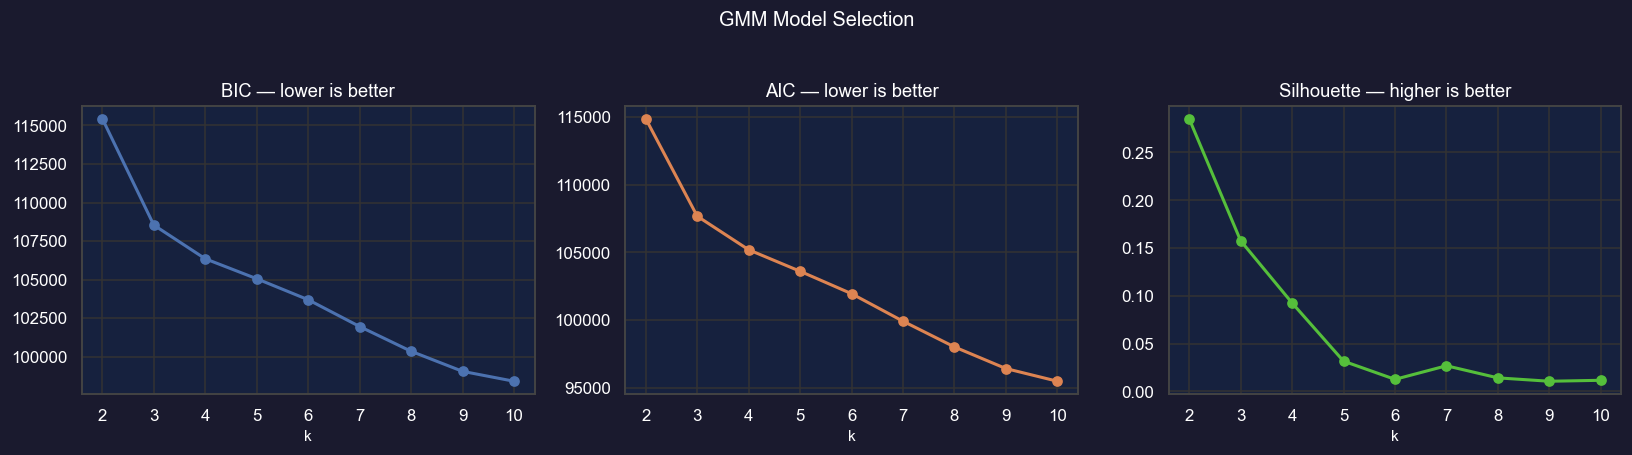

Best k by BIC       : 10
Best k by Silhouette: 2


In [56]:
plots.plot_gmm_selection(list(K_RANGE), bic_scores, aic_scores, sil_scores)

best_k = list(K_RANGE)[int(np.argmin(bic_scores))]
print(f'Best k by BIC       : {best_k}')
print(f'Best k by Silhouette: {list(K_RANGE)[int(np.argmax(sil_scores))]}')

<code>Gender</code> feature is dropped since they showed little relevance in data exploration.

In [57]:
feature_df = feature_df.drop(columns='Gender')


---
## 10. Summary, Findings & Next Steps

### What We Did
- Cleaned data: dropped ID, shuffled, separated targets
- Applied `log1p` to skewed financial variables
- Engineered 3 features; dropped `SophisticationScore` after supervised EDA confirmed redundancy
- Ran unsupervised EDA (distributions, correlation matrix)
- Ran supervised EDA (pairplots, boxplots, point-biserial correlations)
- Reduced feature space with FAMD (8 components)
- Assessed cluster structure with GMM (k = 2…10)

---

### Key Findings

**FAMD:** ~13% total variance across 8 components — no dominant shared latent structure.

**GMM:** No BIC elbow; silhouette scores near zero — no meaningful cluster structure.

**Supervised EDA:** Signal exists but is weak and distributed. `Wealth` and `Age` drive `IncomeInvestment`; `Income` and family-adjusted income drive `AccumulationInvestment`. `Income_Wealth_Ratio_log` is the most discriminative engineered feature.

**What to expect:** ensemble methods (Random Forest, Gradient Boosting) are expected to outperform linear models, since signals are weak and distributed


**Conclusion:** The customer population is a continuous spectrum, not discrete segments. Data-driven clustering is not supported.


---

### What Didn't Work
- GMM / K-Means clustering — no stable segments
- `SophisticationScore` — redundant, dropped
- Therefore, a Mixture of Experts gated by GMM clusters method is not justified by the data


### Next Steps
1. Train classifiers for `IncomeInvestment` and `AccumulationInvestment`
2. Evaluate — ensemble methods (Random Forest, Gradient Boosting) expected to outperform linear models
3. Build recommendation engine on top of predictions

In [58]:
output_path = 'processed_features.xlsx'

with pd.ExcelWriter(output_path) as writer:
    feature_df.to_excel(writer, sheet_name='features', index=True)
   # factors_df.to_excel(writer, sheet_name='famd_factors', index=True)
    df[['IncomeInvestment', 'AccumulationInvestment']].to_excel(
        writer, sheet_name='targets', index=True)

print(f'Saved: {output_path}')
print(f'  features     : {feature_df.shape}')
#print(f'  famd_factors : {factors_df.shape}')
print(f'  targets      : {df[["IncomeInvestment","AccumulationInvestment"]].shape}')

Saved: processed_features.xlsx
  features     : (5000, 9)
  targets      : (5000, 2)


## To-Do List

- Evaluate which transformation best normalizes the distribution of wealth and income, etc .., identifying the most appropriate approach for leptokurtic and skewed wealth data.

- Assess the relevance of the **Gender** feature.

- Explore all cross-multiplications and divisions between features to determine whether any combinations provide useful signal.

- Refactor and organize feature engineering steps (currently scattered throughout the notebook) into a clean and consistent structure in step 5, feature engineering and within the other steps.

- Test the engineered features using the modeling notebook to evaluate whether they improve performance.